# RR Lyrae Period Measurement — Rubin DP2 (local HATS) × VSX
---
This notebook measures pulsation periods for **100 RR Lyrae stars** using:

| Step | Tool |
|------|------|
| Variable-star catalog | VSX via VizieR — constrained to the DC2 bounding box |
| Photometric time series | Rubin DP2 — local HATS catalog via **`lsdb`** |
| Spatial cross-match | `lsdb.crossmatch` (HEALPix-aware) |
| Period analysis | `astropy.timeseries.LombScargle` |
| Validation | LS period vs. VSX reference period |

### Footprint strategy
The DC2 simulation covers **RA 55–75°, Dec −44° to −27°**.  
We pass this bounding box directly as constraints to the VizieR query, so  
only in-field stars are returned — no post-hoc filtering needed.

### Prerequisites
```bash
pip install lsdb astropy astroquery pandas numpy matplotlib
```
> `lsdb` pulls in `dask`, `hats`, and `nested-pandas` automatically.

## 0 · Imports & notebook settings

In [5]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from IPython.display import display

import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.timeseries import LombScargle

from astroquery.vizier import Vizier

import lsdb
import nested_pandas as npd

warnings.filterwarnings("ignore")

%matplotlib inline
plt.rcParams.update({
    "figure.dpi"    : 120,
    "axes.grid"     : True,
    "grid.alpha"    : 0.3,
    "font.size"     : 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
})
print("Imports OK ✓")

Imports OK ✓


## 1 · Configuration

In [22]:
# ── Paths ───────────────────────────────────────────────────────────────────────
HATS_PATH  = Path("/sdf/data/rubin/shared/lsdb_commissioning/hats/v30_0_0_rc2/object_collection")
OUTPUT_DIR = Path("rr_lyrae_output")

# ── DC2 sky footprint (used to constrain the VizieR query) ──────────────────────
DC2_RA_MIN  =  55.0   # deg
DC2_RA_MAX  =  75.0   # deg
DC2_DEC_MIN = -44.0   # deg
DC2_DEC_MAX = -27.0   # deg

# ── Sample settings ──────────────────────────────────────────────────────────────
N_STARS          = 1000    # RR Lyrae to process (VizieR returns at most this many)

# ── Cross-match / light-curve settings ──────────────────────────────────────────
XMATCH_RADIUS    = 1.0    # arcsec
MIN_EPOCHS       = 2     # minimum per-band detections for LS fit

# ── Period search ────────────────────────────────────────────────────────────────
PERIOD_MIN       = 0.2    # days
PERIOD_MAX       = 1.0    # days
LS_FAP_THRESHOLD = 0.01
BAND_PREF        = ["r", "i", "g"]

# ── Display ──────────────────────────────────────────────────────────────────────
PLOT_N = 10

# ── Nested-column schema (update if catalog schema differs) ──────────────────────
LC_COLUMN   = "diaObject_forcedSourceOnDiaObject"
MJD_COL     = "midpointMjdTai"
FLUX_COL    = "psfFlux"
FLUXERR_COL = "psfFluxErr"
BAND_COL    = "band"

VSX_CATALOG = "B/vsx/vsx"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"HATS path   : {HATS_PATH}")
print(f"Output dir  : {OUTPUT_DIR.resolve()}")
print(f"DC2 footprint: RA {DC2_RA_MIN}–{DC2_RA_MAX}°,  "
      f"Dec {DC2_DEC_MIN}–{DC2_DEC_MAX}°")

HATS path   : /sdf/data/rubin/shared/lsdb_commissioning/hats/v30_0_0_rc2/object_collection
Output dir  : /home/b/brantd/notebooks_lf/sprints/2026/03_12/homework_4/rr_lyrae_output
DC2 footprint: RA 55.0–75.0°,  Dec -44.0–-27.0°


## 2 · Open the Local HATS Catalog with `lsdb`

`lsdb.read_hats()` is lazy — it memory-maps the HiPS-partitioned Parquet  
layout without loading any photometry yet.

In [23]:
catalog = lsdb.read_hats(HATS_PATH)
print(catalog)
print()
print("Columns:", catalog.columns.tolist())

Dask NestedFrame Structure:
                           coord_dec    coord_decErr         coord_ra     coord_raErr       g_psfFlux    g_psfFluxErr        g_psfMag     g_psfMagErr       i_psfFlux    i_psfFluxErr        i_psfMag     i_psfMagErr        objectId           patch       r_psfFlux    r_psfFluxErr        r_psfMag     r_psfMagErr          refBand     shape_flag        shape_xx        shape_xy        shape_yy           tract       u_psfFlux    u_psfFluxErr        u_psfMag     u_psfMagErr       y_psfFlux    y_psfFluxErr        y_psfMag     y_psfMagErr       z_psfFlux    z_psfFluxErr        z_psfMag     z_psfMagErr                                                                                                                                                                                                                                                                                                                                                                                       

## 3 · Query VSX — Constrained to the DC2 Bounding Box

`Vizier.query_constraints()` passes coordinate ranges as XML attributes,  
where the `<` character is not well-formed and causes a `TableParseError`.  
Instead we use `query_region()` with a circle that circumscribes the  
bounding box, then clip to the exact rectangle in Python.

In [24]:
def fetch_vsx_in_dc2(ra_min=DC2_RA_MIN, ra_max=DC2_RA_MAX,
                     dec_min=DC2_DEC_MIN, dec_max=DC2_DEC_MAX,
                     n=N_STARS) -> pd.DataFrame:
    """
    Query VSX for RR Lyrae with known periods inside the DC2 bounding box.

    Uses query_region() with a circumscribed circle, then clips to the
    exact rectangle.  Avoids the VizieR XML/VOTable issue where the '<'
    character in '>min <max' column constraints is not well-formed XML.
    """
    ra_centre  = (ra_min  + ra_max)  / 2     # 65.0 deg
    dec_centre = (dec_min + dec_max) / 2     # -35.5 deg
    # Half-diagonal of the box — a circle of this radius fully contains it
    half_diag  = np.hypot(ra_max - ra_centre, dec_max - dec_centre)

    centre = SkyCoord(ra=ra_centre * u.deg, dec=dec_centre * u.deg)
    viz = Vizier(
        columns=["OID", "Name", "RAJ2000", "DEJ2000", "Type", "Period", "max", "min"],
        row_limit=n * 5,           # overrequest; trimmed to box below
        column_filters={"Type": "=RR*"},
    )
    result = viz.query_region(centre, radius=half_diag * u.deg,
                              catalog=VSX_CATALOG)
    if not result:
        raise RuntimeError(
            "VSX returned no results for this sky region.\n"
            "Check that the DC2 bounding box constants are correct."
        )
    tbl = result[0]

    rr_mask    = np.array([str(t).strip().startswith("RR") for t in tbl["Type"]])
    has_period = (~tbl["Period"].mask
                  if hasattr(tbl["Period"], "mask")
                  else np.ones(len(tbl), bool))
    df = tbl[rr_mask & has_period].to_pandas().reset_index(drop=True)
    df["RAJ2000"] = df["RAJ2000"].astype(float)
    df["DEJ2000"] = df["DEJ2000"].astype(float)
    df["OID"]     = df["OID"].astype(str)

    # Trim circle → exact bounding box
    in_box = (
        (df["RAJ2000"] >= ra_min) & (df["RAJ2000"] <= ra_max) &
        (df["DEJ2000"] >= dec_min) & (df["DEJ2000"] <= dec_max)
    )
    return df[in_box].head(n).reset_index(drop=True)

vsx_df = fetch_vsx_in_dc2()
print(f"VSX RR Lyrae in DC2 field: {len(vsx_df)}")
display(vsx_df[["OID", "Name", "RAJ2000", "DEJ2000", "Type", "Period"]].head(10))

VSX RR Lyrae in DC2 field: 186


,OID,Name,RAJ2000,DEJ2000,Type,Period
0,406769,SSS_J034017.1-331611,55.07140,-33.26979,RRAB,0.612650
1,401073,SSS_J034158.5-404431,55.49393,-40.74202,RRAB,0.467490
2,480433,SSS_J034202.7-340152,55.51081,-34.03182,RRAB,0.720034
3,2234971,ASASSN-V J034232.30-310116.5,55.63457,-31.02124,RRAB,0.625561
4,14253,TW For,55.67882,-31.73071,RRAB,0.479100
5,400929,SSS_J034302.5-365254,55.76022,-36.88176,RRAB,0.460940
6,672337,PS1-3PI J034309.57-280729.2,55.78988,-28.12479,RRAB,0.499672
7,480448,SSS_J034335.8-374711,55.89933,-37.78673,RRAB,0.656570
8,480450,SSS_J034340.0-283624,55.91691,-28.60662,RRC,0.381486
9,409014,SSS_J034347.9-300858,55.94943,-30.14943,RRAB,0.955660


### In-field VSX positions and period distribution

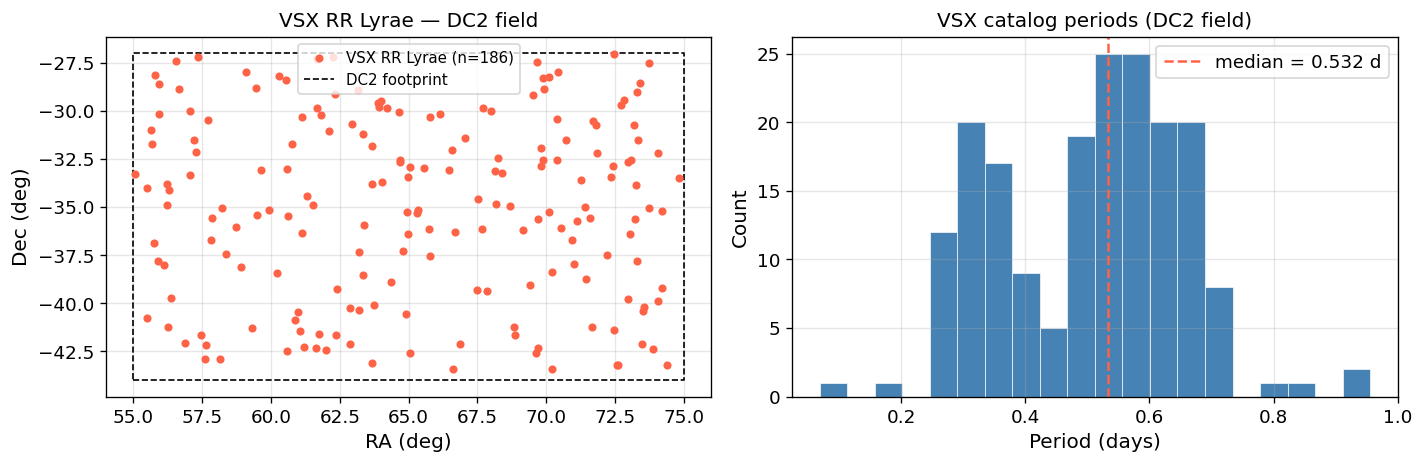

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: sky positions inside the DC2 bounding box
ax = axes[0]
ax.scatter(vsx_df["RAJ2000"], vsx_df["DEJ2000"],
           s=15, color="tomato", zorder=3, label=f"VSX RR Lyrae (n={len(vsx_df)})")
# draw the bounding box
box_ra  = [DC2_RA_MIN,  DC2_RA_MAX,  DC2_RA_MAX,  DC2_RA_MIN,  DC2_RA_MIN]
box_dec = [DC2_DEC_MIN, DC2_DEC_MIN, DC2_DEC_MAX, DC2_DEC_MAX, DC2_DEC_MIN]
ax.plot(box_ra, box_dec, "k--", lw=1, label="DC2 footprint")
ax.set_xlabel("RA (deg)"); ax.set_ylabel("Dec (deg)")
ax.set_title("VSX RR Lyrae — DC2 field")
ax.legend(fontsize=9)

# Right: period histogram
ax2 = axes[1]
pvals = vsx_df["Period"].astype(float).values
ax2.hist(pvals, bins=20, color="steelblue", edgecolor="white", lw=0.4)
ax2.axvline(np.median(pvals), color="tomato", ls="--",
            label=f"median = {np.median(pvals):.3f} d")
ax2.set_xlabel("Period (days)"); ax2.set_ylabel("Count")
ax2.set_title("VSX catalog periods (DC2 field)")
ax2.legend()

plt.tight_layout()

## 4 · Spatial Cross-Match: VSX × HATS

We wrap the VSX positions as an `lsdb` catalog and call `lsdb.crossmatch()`.  
`lsdb` restricts Parquet I/O to the HEALPix pixels that overlap these positions.

In [26]:
vsx_lsdb = lsdb.from_dataframe(
    vsx_df.rename(columns={"RAJ2000": "ra", "DEJ2000": "dec"}),
    ra_column="ra",
    dec_column="dec",
)

xmatch = vsx_lsdb.crossmatch(
    catalog,
    radius_arcsec=XMATCH_RADIUS,
    n_neighbors=1,
    suffixes=("_vsx", "_dp2"),
)

xmatch_df = xmatch.compute()
print(f"Cross-matches found: {len(xmatch_df)} / {len(vsx_df)} VSX stars")
display(xmatch_df.head(5))

Cross-matches found: 2 / 186 VSX stars


OID_vsx                     Name_vsx    ra_vsx   dec_vsx  \
_healpix_29                                                                    
2540201738747635462  480450         SSS_J034340.0-283624  55.91691 -28.60662   
2540279314516724315  672337  PS1-3PI J034309.57-280729.2  55.78988 -28.12479   

                    Type_vsx  Period_vsx  max_vsx  min_vsx  coord_dec_dp2  \
_healpix_29                                                                 
2540201738747635462      RRC    0.381486    16.23     0.42     -28.606657   
2540279314516724315     RRAB    0.499672    17.49     0.86     -28.124816   

                     coord_decErr_dp2  ...  y_psfFlux_dp2  y_psfFluxErr_dp2  \
_healpix_29                            ...                                    
2540201738747635462               0.0  ...           <NA>              <NA>   
2540279314516724315               0.0  ...           <NA>              <NA>   

                     y_psfMag_dp2  y_psfMagErr_dp2  z_psfFlux_dp2  \
_healpix_29                                                         
2540201738747635462          <NA>             <NA>           <NA>   
2540279314516724315          <NA>             <NA>    569785.3125   

                     z_psfFluxErr_dp2  z_psfMag_dp2  z_psfMagErr_dp2  \
_healpix_29                                                            
2540201738747635462              <NA>          <NA>             <NA>   
2540279314516724315        934.777222     17.010721         0.001781   

                                                objectForcedSource_dp2  \
_healpix_29                                                              
2540201738747635462  [{band: 'i', coord_dec: -28.606657, coord_ra: ...   
2540279314516724315  [{band: 'z', coord_dec: -28.124816, coord_ra: ...   

                     _dist_arcsec  
_healpix_29                        
2540201738747635462      0.139163  
2540279314516724315       0.23954  

[2 rows x 46 columns]

## 5 · Unpack Nested Light-Curve Columns

The HATS `object_collection` stores per-epoch photometry in a **nested column**  
(`NestedFrame` from `nested-pandas`).  We explode this into flat per-epoch rows.

In [27]:
def unpack_lightcurves(xmatch_df: pd.DataFrame) -> dict[str, pd.DataFrame]:
    """Explode the nested LC column → {oid: per-epoch DataFrame}."""
    lightcurves = {}

    if LC_COLUMN in xmatch_df.columns:
        for _, row in xmatch_df.iterrows():
            oid = str(row.get("OID_vsx", row.name))
            lc  = row[LC_COLUMN]
            if lc is None or (hasattr(lc, "__len__") and len(lc) == 0):
                continue
            lc_df = (lc.to_flat() if hasattr(lc, "to_flat")
                     else pd.DataFrame(lc))
            lc_df = lc_df.rename(columns={
                MJD_COL: "mjd", FLUX_COL: "flux",
                FLUXERR_COL: "flux_err", BAND_COL: "band",
            })
            if not {"mjd", "flux", "flux_err", "band"}.issubset(lc_df.columns):
                continue
            lc_df = lc_df[["mjd", "flux", "flux_err", "band"]].dropna()
            if len(lc_df) >= MIN_EPOCHS:
                lightcurves[oid] = lc_df
    else:
        print("⚠ Nested column not found — trying flat wide-column schema …")
        for _, row in xmatch_df.iterrows():
            oid, rows = str(row.get("OID_vsx", row.name)), []
            for band in BAND_PREF:
                mc = f"{MJD_COL}_{band}"; fc = f"{FLUX_COL}_{band}"
                ec = f"{FLUXERR_COL}_{band}"
                if all(c in xmatch_df.columns for c in [mc, fc, ec]):
                    rows.append({"mjd": row[mc], "flux": row[fc],
                                 "flux_err": row[ec], "band": band})
            if rows:
                lc_df = pd.DataFrame(rows).dropna()
                if len(lc_df) >= MIN_EPOCHS:
                    lightcurves[oid] = lc_df

    print(f"Light curves unpacked: {len(lightcurves)} / {len(xmatch_df)} "
          f"stars with ≥ {MIN_EPOCHS} epochs")
    return lightcurves

lightcurves = unpack_lightcurves(xmatch_df)

⚠ Nested column not found — trying flat wide-column schema …
Light curves unpacked: 0 / 2 stars with ≥ 2 epochs


### Epoch counts per matched star

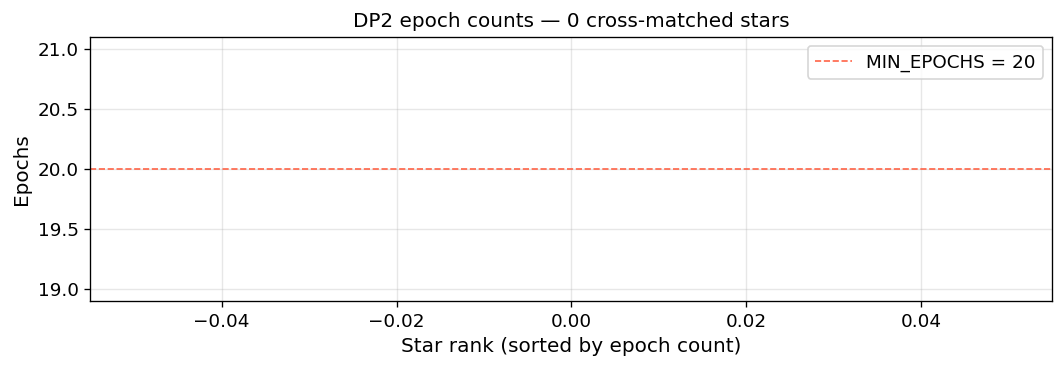

In [21]:
epoch_counts = {oid: len(df) for oid, df in lightcurves.items()}

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.bar(range(len(epoch_counts)),
       sorted(epoch_counts.values(), reverse=True),
       color="steelblue", width=1.0)
ax.axhline(MIN_EPOCHS, color="tomato", ls="--", lw=1,
           label=f"MIN_EPOCHS = {MIN_EPOCHS}")
ax.set_xlabel("Star rank (sorted by epoch count)")
ax.set_ylabel("Epochs")
ax.set_title(f"DP2 epoch counts — {len(epoch_counts)} cross-matched stars")
ax.legend()
plt.tight_layout()

## 6 · Lomb-Scargle Period Measurement

Flux → AB magnitude, then `LombScargle.autopower()` over 0.2–1.0 days.  
Band preference: **r → i → g**.

In [13]:
def flux_to_mag(flux, flux_err, zp=3631.0):
    with np.errstate(divide="ignore", invalid="ignore"):
        mag     = -2.5 * np.log10(flux / zp)
        mag_err = (2.5 / np.log(10)) * np.abs(flux_err / flux)
    return mag, mag_err


def measure_period(df: pd.DataFrame) -> dict:
    for band in BAND_PREF:
        s = df[df["band"] == band].dropna(subset=["mjd", "flux", "flux_err"])
        s = s[s["flux"] > 0]
        if len(s) >= MIN_EPOCHS:
            break
    else:
        return {}

    t   = s["mjd"].values.astype(float)
    mag, mag_err = flux_to_mag(s["flux"].values.astype(float),
                               s["flux_err"].values.astype(float))
    ok  = np.isfinite(mag) & np.isfinite(mag_err) & (mag_err > 0)
    t, mag, mag_err = t[ok], mag[ok], mag_err[ok]
    if len(t) < MIN_EPOCHS:
        return {}

    ls          = LombScargle(t, mag, mag_err)
    freq, power = ls.autopower(
        minimum_frequency=1.0 / PERIOD_MAX,
        maximum_frequency=1.0 / PERIOD_MIN,
        samples_per_peak=10,
    )
    idx = np.argmax(power)
    return dict(
        period_days = 1.0 / freq[idx],
        power       = float(power[idx]),
        fap         = float(ls.false_alarm_probability(power[idx])),
        band        = band,
        n_epochs    = int(len(t)),
        freq        = freq,
        ls_power    = power,
        t=t, mag=mag, mag_err=mag_err,
    )

In [14]:
vsx_period_map = dict(zip(vsx_df["OID"].astype(str),
                          vsx_df["Period"].astype(float)))

records = []
for oid, df in lightcurves.items():
    res = measure_period(df)
    if not res:
        continue
    records.append(dict(
        oid        = oid,
        period_ls  = res["period_days"],
        period_vsx = vsx_period_map.get(oid, np.nan),
        ls_power   = res["power"],
        ls_fap     = res["fap"],
        band       = res["band"],
        n_epochs   = res["n_epochs"],
        freq       = res["freq"],
        ls_pw      = res["ls_power"],
        t          = res["t"],
        mag        = res["mag"],
        mag_err    = res["mag_err"],
    ))

results = pd.DataFrame(records)
print(f"Period measurements: {len(results)} stars")
display(results[["oid","period_ls","period_vsx","ls_fap","band","n_epochs"]].head(10))

Period measurements: 0 stars


KeyError: "None of [Index(['oid', 'period_ls', 'period_vsx', 'ls_fap', 'band', 'n_epochs'], dtype='object')] are in the [columns]"

## 7 · Individual Periodograms

LS power spectrum for the first 6 stars.  
**Red** = LS best period · **Gold dashed** = VSX reference (where available).

In [ ]:
n_show = min(6, len(results))
fig, axes = plt.subplots(n_show, 1, figsize=(10, 2.8 * n_show), sharex=False)
if n_show == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, results.head(n_show).iterrows()):
    ax.plot(1.0 / row["freq"], row["ls_pw"], lw=0.8, color="steelblue")
    ax.axvline(row["period_ls"], color="tomato", lw=1.5,
               label=f"LS = {row['period_ls']:.4f} d")
    if not np.isnan(row["period_vsx"]):
        ax.axvline(row["period_vsx"], color="gold", lw=1.5, ls="--",
                   label=f"VSX = {row['period_vsx']:.4f} d")
    ax.set_xlim(PERIOD_MIN, PERIOD_MAX)
    ax.set_ylabel("LS Power")
    ax.set_title(f"OID {row['oid']}  ·  {row['band']}-band  ·  "
                 f"{row['n_epochs']} pts  ·  FAP = {row['ls_fap']:.2e}")
    ax.legend(fontsize=9, loc="upper right")

axes[-1].set_xlabel("Period (days)")
fig.suptitle("Lomb-Scargle Periodograms", fontsize=13, y=1.01)
plt.tight_layout()

## 8 · Phase-Folded Light Curves

Folded at the LS period, plotted over two cycles.

In [ ]:
n_show = min(PLOT_N, len(results))
ncols, nrows = 2, int(np.ceil(n_show / 2))
band_colors  = {"g": "#4daf4a", "r": "#e41a1c", "i": "#984ea3"}

fig = plt.figure(figsize=(13, 3.4 * nrows))
gs  = gridspec.GridSpec(nrows, ncols, figure=fig, hspace=0.6, wspace=0.35)

for idx, (_, row) in enumerate(results.head(n_show).iterrows()):
    P     = row["period_ls"]
    phase = (row["t"] % P) / P
    order = np.argsort(phase)
    color = band_colors.get(row["band"], "steelblue")
    ax    = fig.add_subplot(gs[idx // ncols, idx % ncols])
    for offset in (0, 1):
        ax.errorbar(phase[order] + offset, row["mag"][order],
                    yerr=row["mag_err"][order],
                    fmt=".", ms=3, elinewidth=0.5, color=color, alpha=0.65)
    ax.invert_yaxis()
    ax.set_xlim(0, 2)
    ax.set_xlabel("Phase"); ax.set_ylabel(f"{row['band']} [mag]")
    vsx_str = (f"  (VSX {row['period_vsx']:.4f} d)"
               if not np.isnan(row["period_vsx"]) else "")
    ax.set_title(f"OID {row['oid']}\nP = {P:.4f} d{vsx_str}", fontsize=10)

fig.suptitle("Phase-Folded RR Lyrae Light Curves — Rubin DP2 (local HATS)",
             fontsize=13)
plt.tight_layout()

## 9 · LS vs VSX Period Comparison

Left: 1:1 scatter coloured by log₁₀(FAP). Alias lines at ½×P and 2×P.  
Right: residual histogram ΔP = P_LS − P_VSX.

In [ ]:
sub = results.dropna(subset=["period_vsx"]).copy()
sub["delta_P"] = sub["period_ls"] - sub["period_vsx"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
sc = ax.scatter(sub["period_vsx"], sub["period_ls"],
                c=np.log10(sub["ls_fap"].clip(1e-20, 1)),
                cmap="viridis_r", s=35, edgecolors="k", lw=0.3, alpha=0.85)
cb = fig.colorbar(sc, ax=ax); cb.set_label("log₁₀(FAP)")
lim = [PERIOD_MIN - 0.02, PERIOD_MAX + 0.02]
ax.plot(lim, lim,               "k--", lw=1, label="1:1")
ax.plot(lim, [x/2 for x in lim], ":", color="tomato",    lw=1, label="½×P")
ax.plot(lim, [x*2 for x in lim], ":", color="steelblue", lw=1, label="2×P")
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("VSX Period (days)"); ax.set_ylabel("LS Period (days)")
ax.set_title("Period recovery: LS vs VSX"); ax.legend(fontsize=9)

ax2 = axes[1]
ax2.hist(sub["delta_P"], bins=25, color="steelblue", edgecolor="white", lw=0.4)
ax2.axvline(0, color="k", lw=1, ls="--")
ax2.axvline(sub["delta_P"].median(), color="tomato", lw=1.5, ls="--",
            label=f"median Δ = {sub['delta_P'].median():.4f} d")
ax2.set_xlabel("ΔP = P_LS − P_VSX (days)"); ax2.set_ylabel("Count")
ax2.set_title("Period residuals"); ax2.legend()

fig.suptitle("Lomb-Scargle Period Recovery — Rubin DP2 RR Lyrae", fontsize=13)
plt.tight_layout()

## 10 · Summary Statistics

In [ ]:
n_sig   = (results["ls_fap"] < LS_FAP_THRESHOLD).sum()
n_cmp   = len(sub)
n_match = sub[(sub["ls_fap"] < LS_FAP_THRESHOLD) &
              (sub["delta_P"].abs() < 0.01)].shape[0]

print(f"{'VSX in-field stars queried':.<45s} {len(vsx_df)}")
print(f"{'Cross-matched in HATS':.<45s} {len(xmatch_df)}")
print(f"{'With ≥ MIN_EPOCHS light-curve points':.<45s} {len(lightcurves)}")
print(f"{'LS period measured':.<45s} {len(results)}")
print(f"{'Significant (FAP < {:.0e})'.format(LS_FAP_THRESHOLD):.<45s} {n_sig}")
if n_cmp:
    print(f"{'Compared to VSX reference':.<45s} {n_cmp}")
    print(f"{'Match within 0.01 d (FAP-sig)':.<45s} {n_match}")
    print(f"{'Median |ΔP|':.<45s} {sub['delta_P'].abs().median():.5f} d")
    print(f"{'RMS ΔP':.<45s} {sub['delta_P'].std():.5f} d")

print()
display(
    results[["oid","period_ls","period_vsx","ls_fap","band","n_epochs"]]
    .sort_values("ls_fap").reset_index(drop=True)
    .style
    .format({"period_ls":"{:.5f}", "period_vsx":"{:.5f}", "ls_fap":"{:.2e}"})
    .background_gradient(subset="ls_fap", cmap="RdYlGn_r")
    .set_caption("RR Lyrae — Lomb-Scargle periods, sorted by FAP")
)

## 11 · Save Results

In [ ]:
csv_path = OUTPUT_DIR / "rr_lyrae_periods.csv"
results[["oid","period_ls","period_vsx","ls_power","ls_fap","band","n_epochs"]]    .to_csv(csv_path, index=False)
print(f"CSV saved  → {csv_path}")

fig_path = OUTPUT_DIR / "period_comparison.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
print(f"Plot saved → {fig_path}")